# VAD データローダー デモノートブック

`autonomous_driving/VAD/dataloader.md` の補足。  
nuScenes 実データ・GPU・mmdet3d 不要。numpy + matplotlib のみで動作。

**目次**
1. nuScenes データ構造（mock）
2. `get_data_info()` のフロー — can_bus 生成と ego_pose 上書き
3. `gt_ego_his_trajs` の計算と可視化
4. `gt_ego_fut_trajs` とドライブコマンド判定
5. BEV シーン可視化（エージェント + 自車軌跡 + HD マップ）

In [1]:
import numpy as np
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
from scipy.spatial.transform import Rotation

warnings.filterwarnings("ignore")
plt.rcParams['font.family'] = 'Noto Sans CJK JP'
plt.rcParams['figure.dpi'] = 120
np.random.seed(42)
print("imports OK")

imports OK


---
## 1. nuScenes データ構造（mock）

nuScenes のテーブル構造：

```
scene  ─── sample (0.5 s 間隔のキーフレーム)
              ├── sample_data  (各センサーの生データへのポインタ)
              ├── ego_pose     (タイムスタンプ別の自車位置・姿勢)
              ├── annotation   (3D bbox)
              └── calibrated_sensor (センサー外部パラメータ)
```

ここでは 12 サンプル（6 秒分）の mock シーンを生成する。

In [2]:
def make_rotation_matrix(yaw: float) -> np.ndarray:
    """Z 軸周りの回転行列 (4x4)"""
    c, s = np.cos(yaw), np.sin(yaw)
    return np.array([[c, -s, 0, 0],
                     [s,  c, 0, 0],
                     [0,  0, 1, 0],
                     [0,  0, 0, 1]], dtype=float)

def make_translation_matrix(tx, ty, tz=0.0) -> np.ndarray:
    T = np.eye(4)
    T[:3, 3] = [tx, ty, tz]
    return T

def make_transform(tx, ty, yaw, tz=0.0) -> np.ndarray:
    return make_translation_matrix(tx, ty, tz) @ make_rotation_matrix(yaw)

# --- mock シーン生成 ---
N_SAMPLES = 12   # 12 サンプル = 6 秒 (0.5 s/sample)
DT = 0.5

# 自車：直進後に左折するシナリオ
ego_positions = []
ego_yaws = []
x, y, yaw = 0.0, 0.0, 0.0
for i in range(N_SAMPLES):
    ego_positions.append((x, y))
    ego_yaws.append(yaw)
    speed = 8.0  # m/s
    if i >= 6:   # 後半は左折
        yaw += np.radians(5)
    x += speed * DT * np.cos(yaw)
    y += speed * DT * np.sin(yaw)

# LiDAR の取り付け位置（ego → LiDAR）: 前方 1.5m, 上方 1.84m
LIDAR_TX, LIDAR_TY, LIDAR_TZ = 1.5, 0.0, 1.84
ego_from_lidar = make_transform(LIDAR_TX, LIDAR_TY, yaw=0.0, tz=LIDAR_TZ)
lidar_from_ego = np.linalg.inv(ego_from_lidar)

# ego_pose テーブル（グローバル座標）
ego_poses = []
for i in range(N_SAMPLES):
    ex, ey = ego_positions[i]
    ey_ = ego_yaws[i]
    T = make_transform(ex, ey, ey_)
    ego_poses.append({
        "token": f"ep_{i:03d}",
        "translation": [ex, ey, 0.0],
        "rotation_yaw": ey_,
        "transform_matrix": T,   # global_from_ego
    })

print(f"mock シーン: {N_SAMPLES} サンプル, DT={DT}s")
print(f"ego_pose[0]  : translation={ego_poses[0]['translation']}, yaw={np.degrees(ego_poses[0]['rotation_yaw']):.1f}°")
print(f"ego_pose[-1] : translation={[f'{v:.2f}' for v in ego_poses[-1]['translation']]}, "
      f"yaw={np.degrees(ego_poses[-1]['rotation_yaw']):.1f}°")
print(f"LiDAR オフセット (ego 座標): tx={LIDAR_TX}, ty={LIDAR_TY}, tz={LIDAR_TZ}")

mock シーン: 12 サンプル, DT=0.5s
ego_pose[0]  : translation=[0.0, 0.0, 0.0], yaw=0.0°
ego_pose[-1] : translation=['43.17', '5.14', '0.00'], yaw=25.0°
LiDAR オフセット (ego 座標): tx=1.5, ty=0.0, tz=1.84


---
## 2. `get_data_info()` のフロー — can_bus と ego_pose 上書き

VAD の `nuscenes_vad_dataset.py` の `get_data_info()` (L1376-1377) では：

```python
can_bus[:3] = translation   # ego_pose の位置で CAN bus の pos を上書き
can_bus[3:7] = rotation     # ego_pose の姿勢で CAN bus の quat を上書き
# can_bus[7:] は生 CAN の加速度・速度データをそのまま使用
```

CAN bus の 18 次元：`[x, y, z, qw, qx, qy, qz, ax, ay, az, vx, vy, vz, yaw_rate, steer, ...]`

=== sample_idx=6 の can_bus ===
  [0:3]  pos (ego_pose 上書き)  : x=24.00, y=0.00, z=0.00
  [3:7]  quat (ego_pose 上書き) : [1. 0. 0. 0.]
  [7:10] 加速度 (生 CAN)        : [ 0.248 -0.069  0.324]
  [10:13] 速度 (生 CAN)         : [8. 0. 0.]
  [13]   yaw_rate (生 CAN)      : 0.1745 rad/s


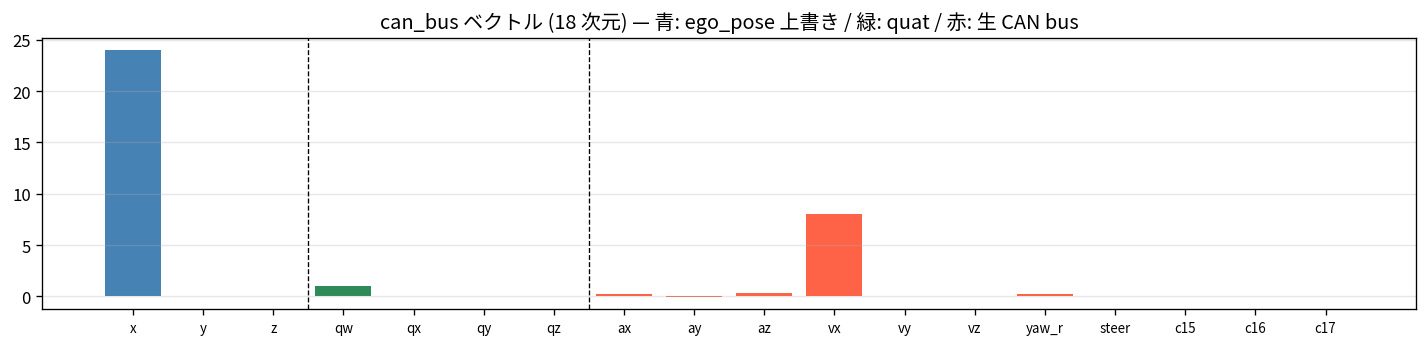

In [3]:
def ego_yaw_to_quat(yaw: float):
    """yaw → quaternion [qw, qx, qy, qz]"""
    return [np.cos(yaw/2), 0.0, 0.0, np.sin(yaw/2)]

def get_data_info(sample_idx: int) -> dict:
    """VAD get_data_info() の簡易再現"""
    ep = ego_poses[sample_idx]

    # Step 1: 生 CAN bus （実際は nuScenes CAN bus API から取得）
    can_bus = np.zeros(18)
    can_bus[7:10]  = np.random.randn(3) * 0.5    # 加速度 ax,ay,az (mock)
    can_bus[10:13] = [8.0 * np.cos(ep['rotation_yaw']),
                      8.0 * np.sin(ep['rotation_yaw']), 0.0]  # 速度 vx,vy,vz
    can_bus[13] = np.radians(5) / DT if sample_idx >= 6 else 0.0  # yaw_rate

    # Step 2: ego_pose で pos/rotation を上書き  ← VAD の核心部分
    translation = ep['translation']
    rotation    = ego_yaw_to_quat(ep['rotation_yaw'])
    can_bus[:3]  = translation    # L1376: can_bus[:3]  = translation
    can_bus[3:7] = rotation       # L1377: can_bus[3:7] = rotation

    return {
        "sample_idx": sample_idx,
        "ego_pose":   ep,
        "can_bus":    can_bus,
    }

# サンプル表示
info = get_data_info(sample_idx=6)
cb = info['can_bus']
print("=== sample_idx=6 の can_bus ===")
print(f"  [0:3]  pos (ego_pose 上書き)  : x={cb[0]:.2f}, y={cb[1]:.2f}, z={cb[2]:.2f}")
print(f"  [3:7]  quat (ego_pose 上書き) : {cb[3:7].round(3)}")
print(f"  [7:10] 加速度 (生 CAN)        : {cb[7:10].round(3)}")
print(f"  [10:13] 速度 (生 CAN)         : {cb[10:13].round(3)}")
print(f"  [13]   yaw_rate (生 CAN)      : {cb[13]:.4f} rad/s")

# can_bus の各フィールドを棒グラフ表示
fig, ax = plt.subplots(figsize=(12, 3))
ax.bar(range(18), cb, color=["steelblue"]*3 + ["seagreen"]*4 + ["tomato"]*11)
ax.set_xticks(range(18))
ax.set_xticklabels(['x','y','z','qw','qx','qy','qz',
                    'ax','ay','az','vx','vy','vz','yaw_r','steer',
                    'c15','c16','c17'], fontsize=8)
ax.set_title("can_bus ベクトル (18 次元) — 青: ego_pose 上書き / 緑: quat / 赤: 生 CAN bus")
ax.axvline(2.5, color='black', linewidth=0.8, linestyle='--')
ax.axvline(6.5, color='black', linewidth=0.8, linestyle='--')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 3. `gt_ego_his_trajs` の計算と可視化

`vad_nuscenes_converter.py` の処理を再現：

1. 現在フレーム `t` の LiDAR グローバル位置を取得
2. `t-2`, `t-1`, `t` の 3 点をグローバル座標で収集（シーン先頭は定速外挿）
3. 全点を現在フレームの **LiDAR 座標系**（`lidar_from_global`）に変換
4. 隣接ステップ間の差分 → shape `[2, 2]`（x, y のみ）

```
[t-2→t-1 の (dx,dy),  t-1→t の (dx,dy)]
```

=== gt_ego_his_trajs (t=8) ===
グローバル位置:
  t-2: global=(25.50, 0.00)  →  LiDAR=(-8.01, 0.09)
  t-1: global=(29.48, 0.48)  →  LiDAR=(-4.01, -0.13)
   t : global=(33.40, 1.30)  →  LiDAR=(-0.00, 0.00)
gt_ego_his_trajs =
[[ 4.002 -0.219]
 [ 4.006  0.131]]
  shape: (2, 2)  (t-2→t-1, t-1→t)


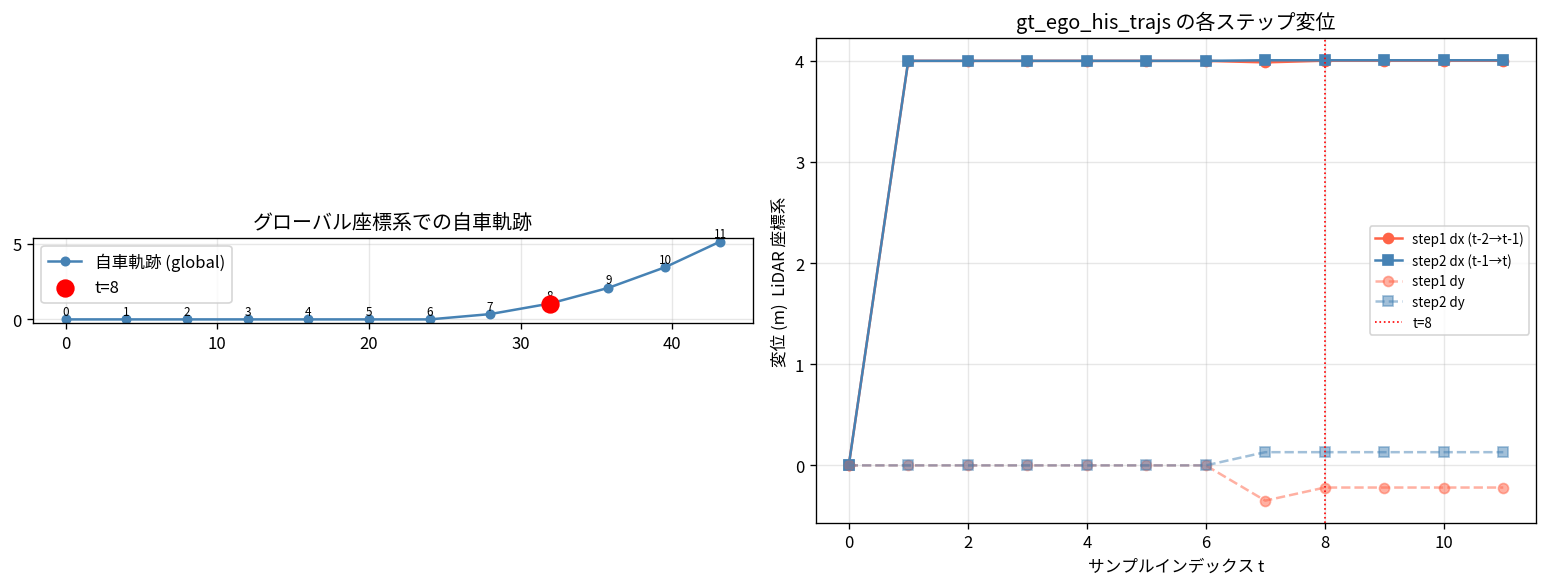

In [4]:
def get_global_lidar_pos(sample_idx: int) -> np.ndarray:
    """ego_pose + LiDAR キャリブから LiDAR のグローバル位置を返す (x, y, z)"""
    ep = ego_poses[sample_idx]
    global_from_ego   = ep['transform_matrix']
    global_from_lidar = global_from_ego @ ego_from_lidar
    return global_from_lidar[:3, 3]   # 平行移動成分 = グローバル位置

def compute_ego_his_trajs(t: int) -> np.ndarray:
    """gt_ego_his_trajs を計算。shape: [2, 2]"""
    # 過去 3 点のグローバル位置
    if t >= 2:
        pts_global = [get_global_lidar_pos(t-2),
                      get_global_lidar_pos(t-1),
                      get_global_lidar_pos(t)]
    elif t == 1:
        p0 = get_global_lidar_pos(0)
        p1 = get_global_lidar_pos(1)
        # t-2 は定速外挿（VAD の処理）
        pts_global = [p0 - (p1 - p0), p0, p1]
    else:  # t == 0
        p0 = get_global_lidar_pos(0)
        pts_global = [p0, p0, p0]

    # 現フレームの lidar_from_global
    ep_t = ego_poses[t]
    global_from_ego_t   = ep_t['transform_matrix']
    global_from_lidar_t = global_from_ego_t @ ego_from_lidar
    lidar_from_global_t = np.linalg.inv(global_from_lidar_t)

    # グローバル → LiDAR 座標変換
    def to_lidar(p):
        ph = np.array([p[0], p[1], p[2], 1.0])
        return (lidar_from_global_t @ ph)[:2]  # x, y のみ

    pts_lidar = [to_lidar(p) for p in pts_global]

    # per-step diff
    diffs = np.array([pts_lidar[1] - pts_lidar[0],
                      pts_lidar[2] - pts_lidar[1]])  # [2, 2]
    return diffs, pts_lidar, pts_global


# --- t=8 での計算 ---
T_IDX = 8
diffs, pts_lidar, pts_global = compute_ego_his_trajs(T_IDX)

print(f"=== gt_ego_his_trajs (t={T_IDX}) ===")
print(f"グローバル位置:")
for i, (pg, pl) in enumerate(zip(pts_global, pts_lidar)):
    label = ["t-2", "t-1", " t "][i]
    print(f"  {label}: global=({pg[0]:.2f}, {pg[1]:.2f})  →  LiDAR=({pl[0]:.2f}, {pl[1]:.2f})")
print(f"gt_ego_his_trajs =\n{diffs.round(3)}")
print(f"  shape: {diffs.shape}  (t-2→t-1, t-1→t)")

# --- 全サンプルの his_trajs を可視化 ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 左: グローバル軌跡
gx = [ep['translation'][0] for ep in ego_poses]
gy = [ep['translation'][1] for ep in ego_poses]
axes[0].plot(gx, gy, 'o-', color='steelblue', markersize=5, label='自車軌跡 (global)')
for i, (x_, y_) in enumerate(zip(gx, gy)):
    axes[0].text(x_, y_ + 0.3, str(i), fontsize=7, ha='center')
axes[0].scatter([gx[T_IDX]], [gy[T_IDX]], s=100, color='red', zorder=5, label=f't={T_IDX}')
axes[0].set_aspect('equal')
axes[0].set_title('グローバル座標系での自車軌跡')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 右: LiDAR 座標系での his_trajs (dx, dy 累積)
all_diffs = [compute_ego_his_trajs(t)[0] for t in range(N_SAMPLES)]
t_indices = list(range(N_SAMPLES))
dx_1 = [d[0, 0] for d in all_diffs]   # t-2→t-1
dy_1 = [d[0, 1] for d in all_diffs]
dx_2 = [d[1, 0] for d in all_diffs]   # t-1→t
dy_2 = [d[1, 1] for d in all_diffs]

axes[1].plot(t_indices, dx_1, 'o-', label='step1 dx (t-2→t-1)', color='tomato')
axes[1].plot(t_indices, dx_2, 's-', label='step2 dx (t-1→t)',   color='steelblue')
axes[1].plot(t_indices, dy_1, 'o--', label='step1 dy', color='tomato', alpha=0.5)
axes[1].plot(t_indices, dy_2, 's--', label='step2 dy', color='steelblue', alpha=0.5)
axes[1].axvline(T_IDX, color='red', linewidth=1, linestyle=':', label=f't={T_IDX}')
axes[1].set_xlabel('サンプルインデックス t')
axes[1].set_ylabel('変位 (m)  LiDAR 座標系')
axes[1].set_title('gt_ego_his_trajs の各ステップ変位')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 4. `gt_ego_fut_trajs` とドライブコマンド判定

未来 6 ステップ（3 秒分）の軌跡。  
シーン末尾はラスト位置で静止埋め（VAD の処理）。

**ドライブコマンド判定**（`ego_fut_trajs[-1][0]` = 最後点の x 変位で判定）：
- `x ≥ 2m` → **right turn**
- `x ≤ -2m` → **left turn**
- それ以外 → **straight / stop**

t=4: コマンド = [right turn]  最終累積 x=23.46m, y=3.96m
  gt_ego_fut_trajs =
[[4.    0.   ]
 [4.    0.   ]
 [3.979 0.479]
 [3.922 0.824]
 [3.835 1.163]
 [3.719 1.493]]

t=8: コマンド = [right turn]  最終累積 x=11.74m, y=2.47m
  gt_ego_fut_trajs =
[[3.979 0.479]
 [3.922 0.824]
 [3.835 1.163]
 [0.    0.   ]
 [0.    0.   ]
 [0.    0.   ]]



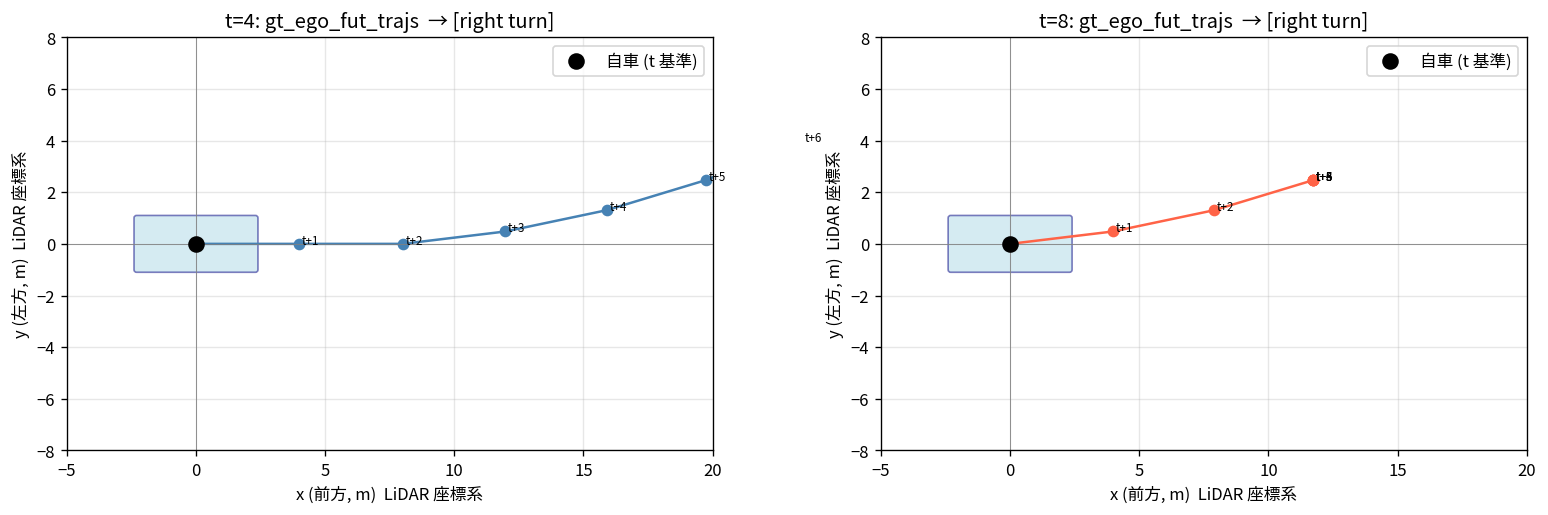

In [5]:
FUT_STEPS = 6

def compute_ego_fut_trajs(t: int):
    """gt_ego_fut_trajs を計算。shape: [6, 2]"""
    # 未来 t, t+1, ..., t+6 の位置（シーン末尾はラスト位置で埋め）
    pts_global = []
    last_valid = min(t + FUT_STEPS, N_SAMPLES - 1)
    for i in range(t, t + FUT_STEPS + 1):
        idx = min(i, last_valid)
        pts_global.append(get_global_lidar_pos(idx))

    # lidar_from_global（現フレーム基準）
    ep_t = ego_poses[t]
    global_from_lidar_t = ep_t['transform_matrix'] @ ego_from_lidar
    lidar_from_global_t = np.linalg.inv(global_from_lidar_t)

    def to_lidar(p):
        ph = np.array([p[0], p[1], p[2], 1.0])
        return (lidar_from_global_t @ ph)[:2]

    pts_lidar = [to_lidar(p) for p in pts_global]

    # per-step diff
    diffs = np.array([pts_lidar[i+1] - pts_lidar[i] for i in range(FUT_STEPS)])  # [6, 2]

    # ドライブコマンド判定: 累積位置の最終 x を見る
    cumulative = np.cumsum(diffs, axis=0)   # [6, 2]  累積変位
    last_x = cumulative[-1, 0]
    if last_x >= 2.0:
        cmd = "right turn"
    elif last_x <= -2.0:
        cmd = "left turn"
    else:
        cmd = "straight / stop"

    return diffs, cumulative, cmd


# --- t=4（直進）と t=8（左折中）で比較 ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, t, color in [(axes[0], 4, 'steelblue'), (axes[1], 8, 'tomato')]:
    diffs, cum, cmd = compute_ego_fut_trajs(t)
    print(f"t={t}: コマンド = [{cmd}]  最終累積 x={cum[-1,0]:.2f}m, y={cum[-1,1]:.2f}m")
    print(f"  gt_ego_fut_trajs =\n{diffs.round(3)}\n")

    # LiDAR 座標系での軌跡プロット（自車 = 原点）
    xs = np.concatenate([[0], cum[:, 0]])
    ys = np.concatenate([[0], cum[:, 1]])
    ax.plot(xs, ys, 'o-', color=color)
    ax.scatter([0], [0], s=80, color='black', zorder=5, label='自車 (t 基準)')
    for i, (xi, yi) in enumerate(zip(xs[1:], ys[1:]), 1):
        ax.text(xi + 0.1, yi, f't+{i}', fontsize=7)

    # 自車を矩形で表示
    car = mpatches.FancyBboxPatch((-2.3, -1.0), 4.6, 2.0,
                                  boxstyle="round,pad=0.1",
                                  facecolor='lightblue', edgecolor='navy', alpha=0.5)
    ax.add_patch(car)
    ax.set_aspect('equal')
    ax.set_xlim(-5, 20)
    ax.set_ylim(-8, 8)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
    ax.set_xlabel('x (前方, m)  LiDAR 座標系')
    ax.set_ylabel('y (左方, m)  LiDAR 座標系')
    ax.set_title(f't={t}: gt_ego_fut_trajs  → [{cmd}]')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 5. BEV シーン可視化

Bird's Eye View（俯瞰図）で以下を描画：
- 自車（青矩形）+ 現在位置マーカー
- 過去軌跡 `gt_ego_his_trajs`（赤）
- 未来軌跡 `gt_ego_fut_trajs`（橙）
- 他エージェント（mock: ランダム配置の車・歩行者）
- HD マップ（mock: レーン境界線）

すべて現在フレームの **LiDAR 座標系** で描画。

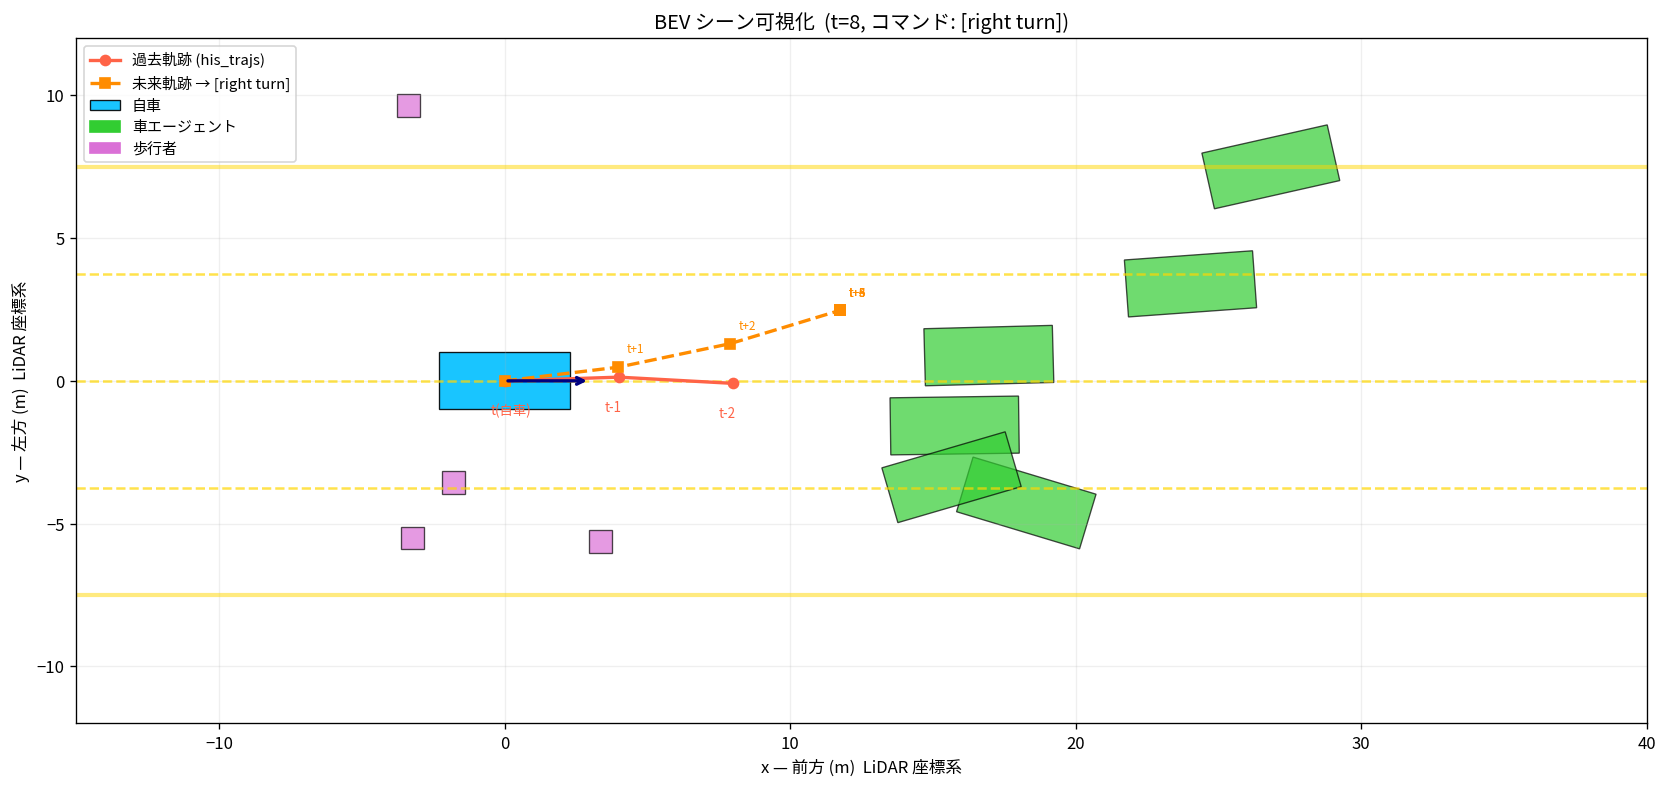

In [6]:
def draw_rotated_box(ax, cx, cy, length, width, yaw, color, alpha=0.8, label=None):
    """BEV 上に回転矩形を描画"""
    corners = np.array([[ length/2,  width/2],
                         [-length/2,  width/2],
                         [-length/2, -width/2],
                         [ length/2, -width/2]])
    c, s = np.cos(yaw), np.sin(yaw)
    R = np.array([[c, -s], [s, c]])
    corners = (R @ corners.T).T + np.array([cx, cy])
    poly = plt.Polygon(corners, closed=True, facecolor=color,
                       edgecolor='black', alpha=alpha, linewidth=0.8, label=label)
    ax.add_patch(poly)

T_BEV = 8   # 可視化するフレーム

# --- 過去軌跡（LiDAR 座標系での累積位置）---
his_diffs, _, _ = compute_ego_his_trajs(T_BEV)
his_cum = np.vstack([np.cumsum(his_diffs[::-1], axis=0)[::-1], [[0, 0]]])
his_pts = his_cum  # [t-2相対, t-1相対, origin(0,0)]

# --- 未来軌跡 ---
fut_diffs, fut_cum, drive_cmd = compute_ego_fut_trajs(T_BEV)
fut_pts = np.vstack([[0, 0], fut_cum])

# --- mock エージェント（LiDAR 座標系でランダム配置）---
np.random.seed(T_BEV)
agents = []
for _ in range(6):    # 車
    x = np.random.uniform(5, 30)
    y = np.random.uniform(-8, 8)
    yaw = np.random.uniform(-0.3, 0.3)
    agents.append({'type': 'car', 'x': x, 'y': y, 'yaw': yaw, 'l': 4.5, 'w': 2.0})
for _ in range(4):    # 歩行者
    x = np.random.uniform(-5, 20)
    y = np.random.uniform(-10, 10)
    agents.append({'type': 'ped', 'x': x, 'y': y, 'yaw': 0, 'l': 0.8, 'w': 0.8})

# --- mock HD マップ（直線レーン 2 本）---
lane_y = [-3.75, 0.0, 3.75]  # レーン境界 y 座標

# --- 描画 ---
fig, ax = plt.subplots(figsize=(14, 8))

# HD マップ（レーン境界）
for ly in lane_y:
    ax.axhline(ly, color='gold', linewidth=1.5, linestyle='--', alpha=0.7)
ax.axhline(-7.5, color='gold', linewidth=2.5, alpha=0.5)
ax.axhline( 7.5, color='gold', linewidth=2.5, alpha=0.5)

# エージェント
for ag in agents:
    color = 'limegreen' if ag['type'] == 'car' else 'orchid'
    draw_rotated_box(ax, ag['x'], ag['y'], ag['l'], ag['w'], ag['yaw'], color, alpha=0.7)

# 過去軌跡
ax.plot(his_pts[:, 0], his_pts[:, 1], 'o-', color='tomato',
        linewidth=2, markersize=6, label='過去軌跡 (his_trajs)')
for i, (xi, yi) in enumerate(his_pts):
    labels = ['t-2', 't-1', 't(自車)']
    ax.text(xi - 0.5, yi - 1.2, labels[i], fontsize=8, color='tomato')

# 未来軌跡
ax.plot(fut_pts[:, 0], fut_pts[:, 1], 's--', color='darkorange',
        linewidth=2, markersize=6, label=f'未来軌跡 → [{drive_cmd}]')
for i, (xi, yi) in enumerate(fut_pts[1:], 1):
    ax.text(xi + 0.3, yi + 0.5, f't+{i}', fontsize=7, color='darkorange')

# 自車（原点）
draw_rotated_box(ax, 0, 0, 4.6, 2.0, 0, 'deepskyblue', alpha=0.9, label='自車')
ax.annotate('', xy=(3, 0), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='navy', lw=2))

# 凡例・軸
car_patch = mpatches.Patch(color='limegreen', label='車エージェント')
ped_patch = mpatches.Patch(color='orchid',    label='歩行者')
ax.set_xlim(-15, 40)
ax.set_ylim(-12, 12)
ax.set_aspect('equal')
ax.set_xlabel('x — 前方 (m)  LiDAR 座標系')
ax.set_ylabel('y — 左方 (m)  LiDAR 座標系')
ax.set_title(f'BEV シーン可視化  (t={T_BEV}, コマンド: [{drive_cmd}])')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles + [car_patch, ped_patch],
          labels  + ['車エージェント', '歩行者'],
          loc='upper left', fontsize=9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()